In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"IPL.csv") 

In [3]:
df.head(5)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [4]:
df.shape

(74, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [6]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

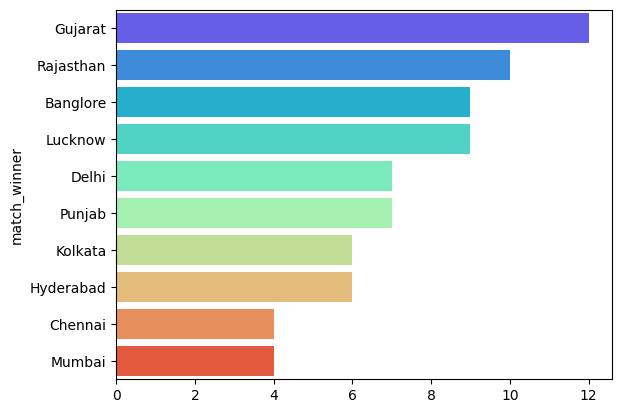

In [7]:
#which team won the most matches?
match_wins=df["match_winner"].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values,palette="rainbow")
plt.show()

<Axes: xlabel='toss_decision', ylabel='count'>

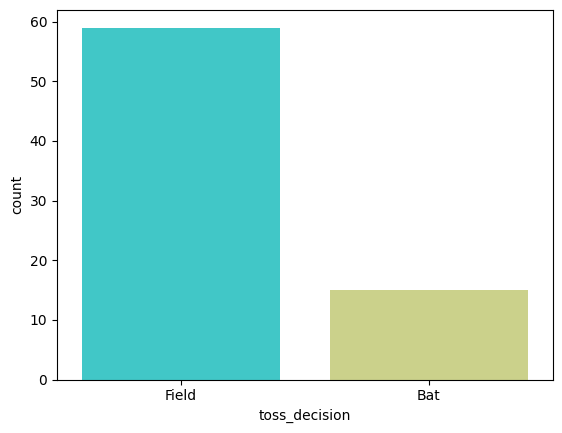

In [8]:
# Toss Decision Trends
sns.countplot(x=df["toss_decision"],palette="rainbow")

In [9]:
#Toss winners vs match winner
print(df[df["toss_winner"]==df["match_winner"]]["match_id"].count())

36


<Axes: xlabel='won_by', ylabel='count'>

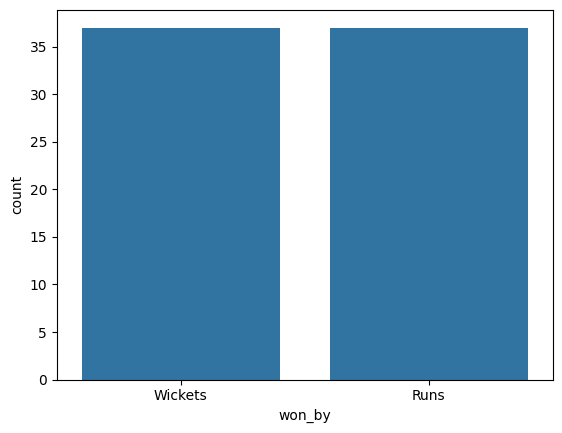

In [10]:
#How to teams win ?(Runs VS Wickets)
df["won_by"].value_counts()
sns.countplot(x=df["won_by"])

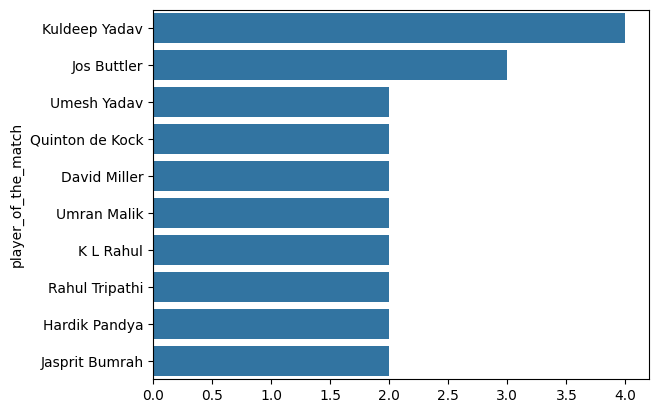

In [11]:
#Most players of the Match "Awards"
count=df["player_of_the_match"].value_counts().head(10)
sns.barplot(y=count.index,x=count.values)
plt.show()

In [12]:
# 2 Top_scorer
df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(2)


top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

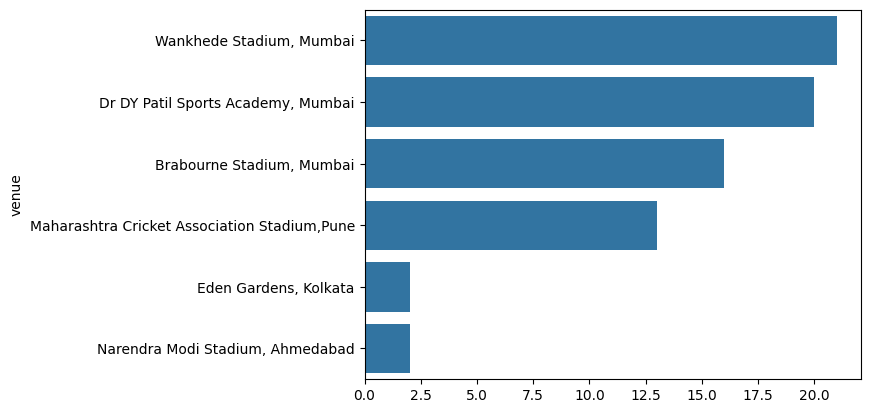

In [13]:
#Most Matches played by Venue
venue_count=df["venue"].value_counts()
sns.barplot(y=venue_count.index,x=venue_count.values)
plt.show()

In [14]:
# who won the highest margin by runs?
df[df["won_by"]=="Runs"].sort_values(by="margin",ascending=False).head(1)[["match_winner","margin"]]

,match_winner,margin
54,Chennai,91


In [15]:
#which player had the highest individual score 
df[df["highscore"]==df["highscore"].max()][["top_scorer","highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140
